# TPC-DS Benchmark Results Analysis
**Fabric Lakehouse SQL Endpoint vs Fabric Warehouse**

This notebook loads benchmark results from `results/` and produces:
- Summary statistics (median, p90, p95) per endpoint, query and scale factor
- Cold vs. warm cache comparison
- Lakehouse table configuration comparison (default / partitioned / zorder / vorder)
- Bar charts and box plots of query latency

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load results

In [2]:
RESULTS_DIR = '../results'

csv_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'benchmark_*.csv')))
print(f'Found {len(csv_files)} result file(s):')
for f in csv_files:
    print(' ', f)

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'\nTotal rows: {len(df):,}')
df.head()

Found 5 result file(s):
  ../results\benchmark_20260410T160604.csv
  ../results\benchmark_20260429T171514.csv
  ../results\benchmark_20260430T063923.csv
  ../results\benchmark_20260430T065849.csv
  ../results\benchmark_20260430T173519.csv

Total rows: 260


,run_id,timestamp,endpoint,scale_factor,query_id,cache_mode,repetition,elapsed_ms,rows_returned,status,error_message
0,c9541237-a5de-422b-891e-0ed91e488b64,2026-04-10 15:59:16.325933+00:00,lakehouse_default,SF100,q01,cold,1,7706.55,960,success,NaN
1,a76caf26-2912-4730-8fa0-0befa5a91e9a,2026-04-10 15:59:22.571630+00:00,lakehouse_default,SF100,q02,cold,1,5045.15,100,success,NaN
2,42cc6be9-a42f-4081-a8dc-14bab842b9a8,2026-04-10 15:59:25.379060+00:00,lakehouse_default,SF100,q03,cold,1,1510.88,10,success,NaN
3,1e28db67-3d26-47aa-8cd4-ad1814c97d1d,2026-04-10 15:59:32.273857+00:00,lakehouse_default,SF100,q04,cold,1,5805.39,0,success,NaN
4,25435308-5b00-483c-8163-cfeb691b13ce,2026-04-10 15:59:43.815684+00:00,lakehouse_default,SF100,q05,cold,1,10539.70,200,success,NaN


## 2. Data quality check

In [3]:
print('Status breakdown:')
print(df['status'].value_counts())
print()

# Filter to successful runs only
df_ok = df[df['status'] == 'success'].copy()
print(f'Successful runs: {len(df_ok):,} / {len(df):,}')
print()
print('Endpoints present:', df_ok['endpoint'].unique().tolist())
print('Scale factors:',     df_ok['scale_factor'].unique().tolist())
print('Queries:',           df_ok['query_id'].unique().tolist())

Status breakdown:
status
success    185
timeout     75
Name: count, dtype: int64

Successful runs: 185 / 260

Endpoints present: ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse', 'warehouse_frag', 'lakehouse_frag']
Scale factors: ['SF100']
Queries: ['q01', 'q02', 'q03', 'q04', 'q05']


## 3. Summary statistics (median / p90 / p95)

In [4]:
def pct(p):
    return lambda x: x.quantile(p / 100)

summary = (
    df_ok
    .groupby(['scale_factor', 'endpoint', 'query_id', 'cache_mode'])['elapsed_ms']
    .agg(
        median=pct(50),
        p90=pct(90),
        p95=pct(95),
        mean='mean',
        count='count'
    )
    .reset_index()
    .sort_values(['scale_factor', 'cache_mode', 'query_id', 'median'])
)
summary

,scale_factor,endpoint,query_id,cache_mode,median,p90,p95,mean,count
15,SF100,lakehouse_partitioned,q01,cold,1799.180,1799.180,1799.1800,1799.180000,1
35,SF100,warehouse,q01,cold,4154.280,4154.280,4154.2800,4154.280000,1
25,SF100,lakehouse_vorder,q01,cold,4262.620,4262.620,4262.6200,4262.620000,1
0,SF100,lakehouse_default,q01,cold,7706.550,7706.550,7706.5500,7706.550000,1
17,SF100,lakehouse_partitioned,q02,cold,3546.490,3546.490,3546.4900,3546.490000,1
37,SF100,warehouse,q02,cold,4368.600,4368.600,4368.6000,4368.600000,1
2,SF100,lakehouse_default,q02,cold,5045.150,5045.150,5045.1500,5045.150000,1
27,SF100,lakehouse_vorder,q02,cold,5288.060,5288.060,5288.0600,5288.060000,1
19,SF100,lakehouse_partitioned,q03,cold,1059.060,1059.060,1059.0600,1059.060000,1
4,SF100,lakehouse_default,q03,cold,1510.880,1510.880,1510.8800,1510.880000,1


## 4. Cold vs. warm - median latency per query

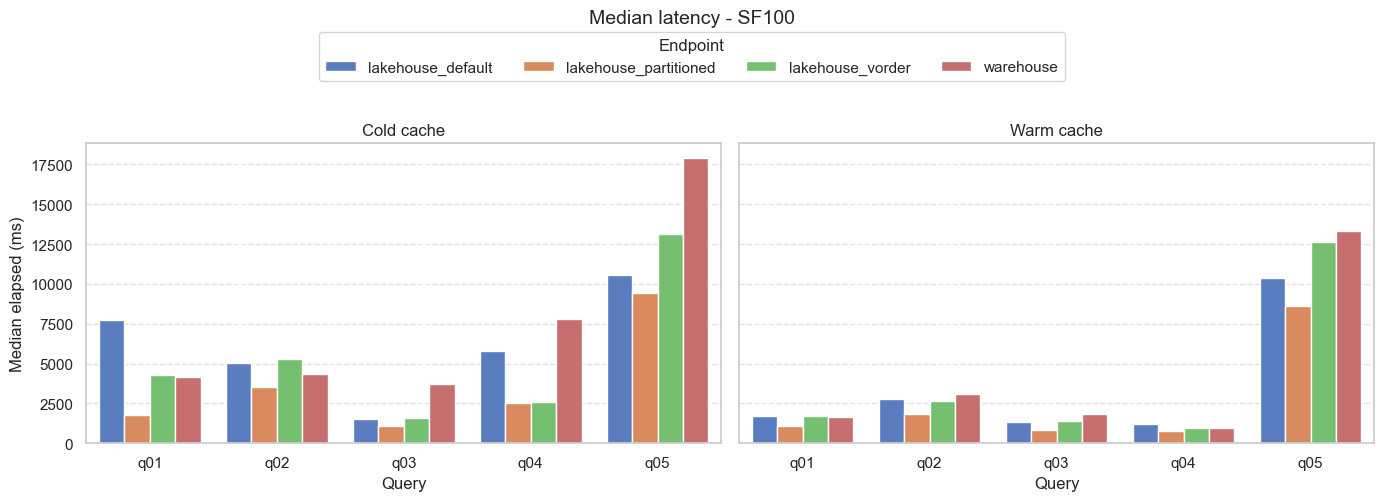

In [5]:
ENDPOINT_ORDER = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse']

for sf in sorted(df_ok['scale_factor'].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f'Median latency - {sf}', fontsize=14, y=1.0)

    for ax, cache_mode in zip(axes, ['cold', 'warm']):
        data = summary[
            (summary['scale_factor'] == sf) &
            (summary['cache_mode'] == cache_mode)
        ]
        sns.barplot(
            data=data, x='query_id', y='median',
            hue='endpoint', hue_order=ENDPOINT_ORDER, ax=ax
        )
        ax.set_title(f'{cache_mode.capitalize()} cache')
        ax.set_xlabel('Query')
        ax.set_ylabel('Median elapsed (ms)' if cache_mode == 'cold' else '')
        ax.yaxis.grid(True, linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Endpoint',
        loc='upper center',
        bbox_to_anchor=(0.5, 0.97),
        ncol=len(ENDPOINT_ORDER),
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

## 5. Lakehouse config comparison (warm, all queries)

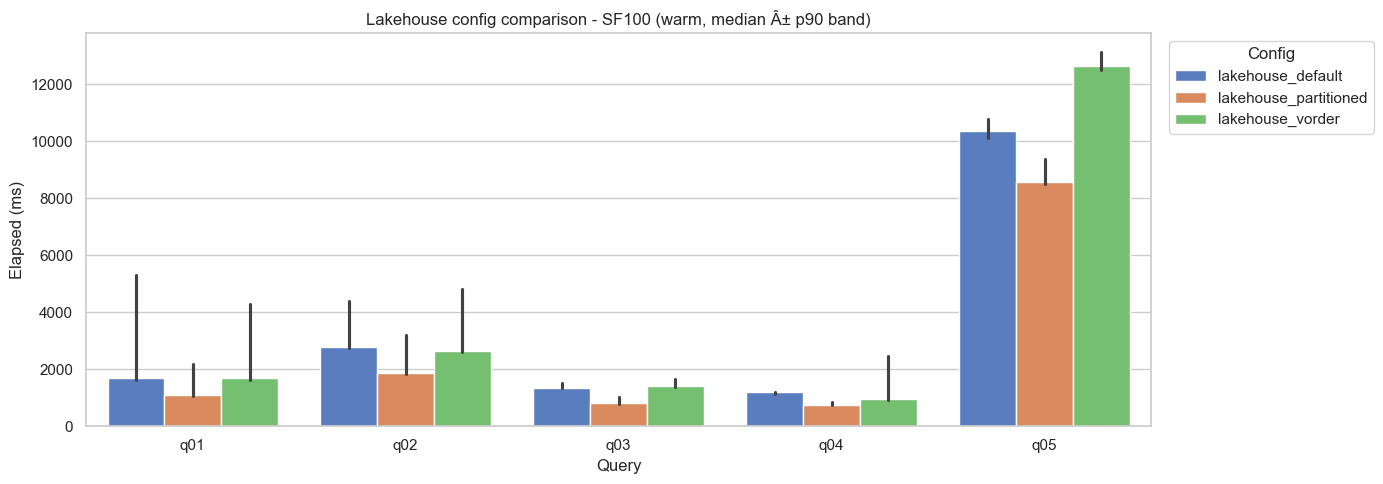

In [6]:
lh_endpoints = [e for e in df_ok['endpoint'].unique()
                if e.startswith('lakehouse_') and not e.endswith('_frag')]
df_lh = df_ok[(df_ok['endpoint'].isin(lh_endpoints)) & (df_ok['cache_mode'] == 'warm')]

for sf in sorted(df_lh['scale_factor'].unique()):
    data = df_lh[df_lh['scale_factor'] == sf]
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=data, x='query_id', y='elapsed_ms', hue='endpoint', ax=ax,
                estimator='median', errorbar=('pi', 90))
    ax.set_title(f'Lakehouse config comparison - {sf} (warm, median Â± p90 band)')
    ax.set_xlabel('Query')
    ax.set_ylabel('Elapsed (ms)')
    ax.legend(title='Config', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 6. Distribution - box plots (warm)

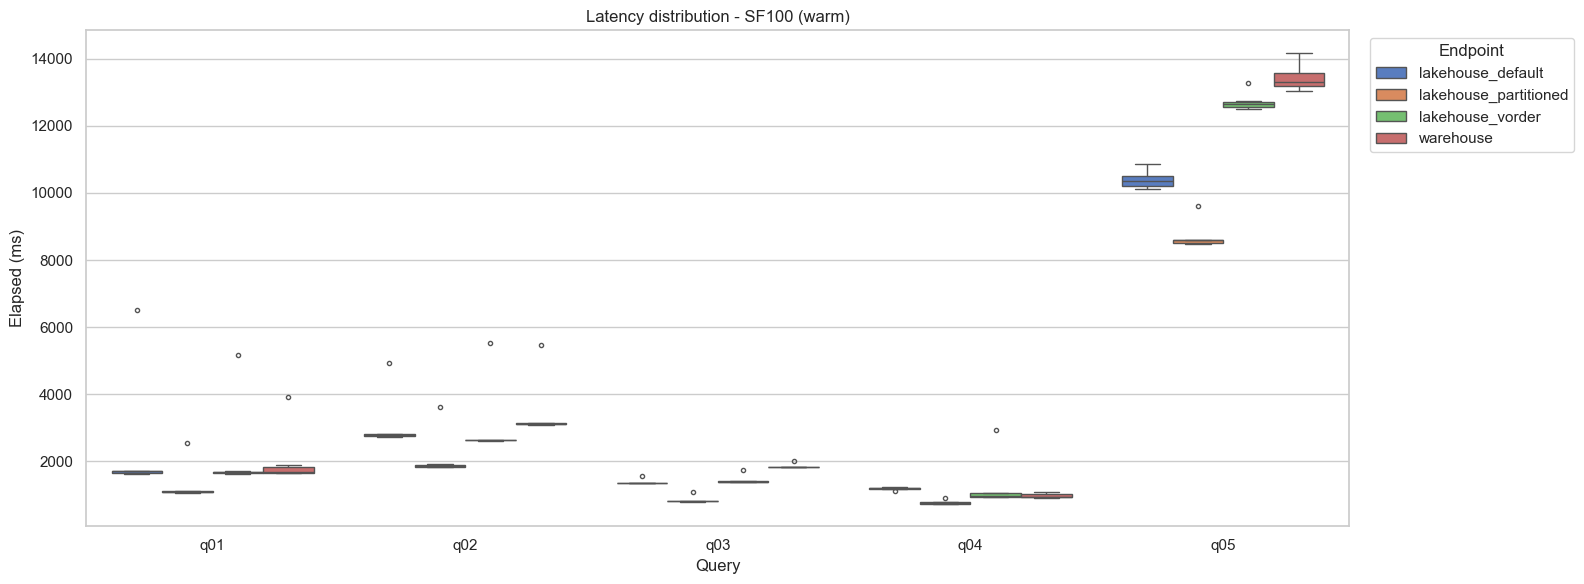

In [7]:
for sf in sorted(df_ok['scale_factor'].unique()):
    _compact = ~df_ok['endpoint'].str.endswith('_frag')
    data = df_ok[(df_ok['scale_factor'] == sf) & (df_ok['cache_mode'] == 'warm') & _compact]
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=data, x='query_id', y='elapsed_ms', hue='endpoint', ax=ax,
                flierprops=dict(marker='o', markersize=3))
    ax.set_title(f'Latency distribution - {sf} (warm)')
    ax.set_xlabel('Query')
    ax.set_ylabel('Elapsed (ms)')
    ax.legend(title='Endpoint', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 7. Lakehouse vs Warehouse - aggregate comparison

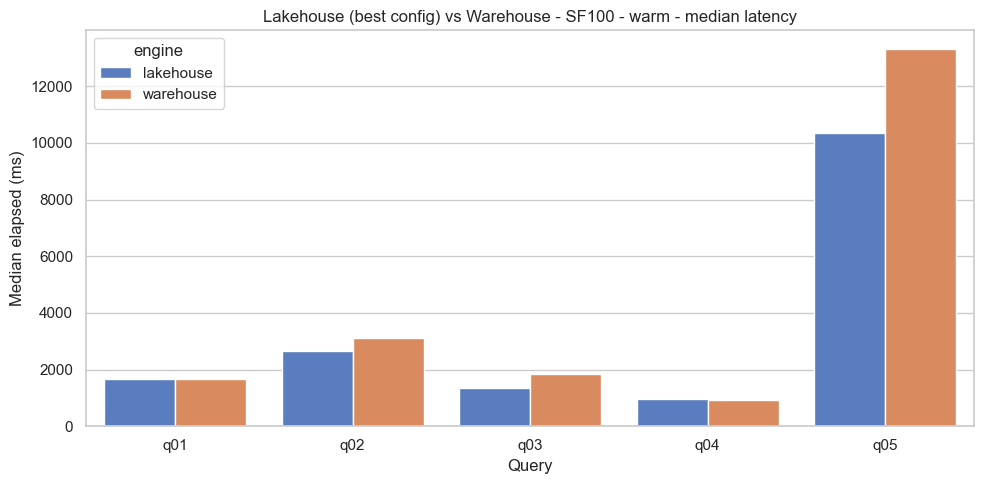

In [8]:
_COMPACT_EPS = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder', 'warehouse']
df_compact = df_ok[df_ok['endpoint'].isin(_COMPACT_EPS)].copy()
df_compact['engine'] = df_compact['endpoint'].apply(
    lambda e: 'warehouse' if e == 'warehouse' else 'lakehouse'
)
engine_summary = (
    df_compact[df_compact['cache_mode'] == 'warm']
    .groupby(['scale_factor', 'engine', 'query_id'])['elapsed_ms']
    .median()
    .reset_index()
    .rename(columns={'elapsed_ms': 'median_ms'})
)

for sf in sorted(engine_summary['scale_factor'].unique()):
    data = engine_summary[engine_summary['scale_factor'] == sf]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=data, x='query_id', y='median_ms', hue='engine', ax=ax)
    ax.set_title(f'Lakehouse (best config) vs Warehouse - {sf} - warm - median latency')
    ax.set_xlabel('Query')
    ax.set_ylabel('Median elapsed (ms)')
    plt.tight_layout()
    plt.show()

## 8. Fragmentation experiment

Analyzes warm-cache results for `warehouse_frag` and `lakehouse_frag` endpoints.
Only shown when result files include fragmented endpoint rows.

**8.1** Individual executions - every repetition, linear scale, independent Y per endpoint.  
**8.2** Average latency - mean of 3 reps, two subplots with independent Y, Ã—N slowdown vs WH.  
**8.3** Compact vs. fragmented - median comparison per engine.

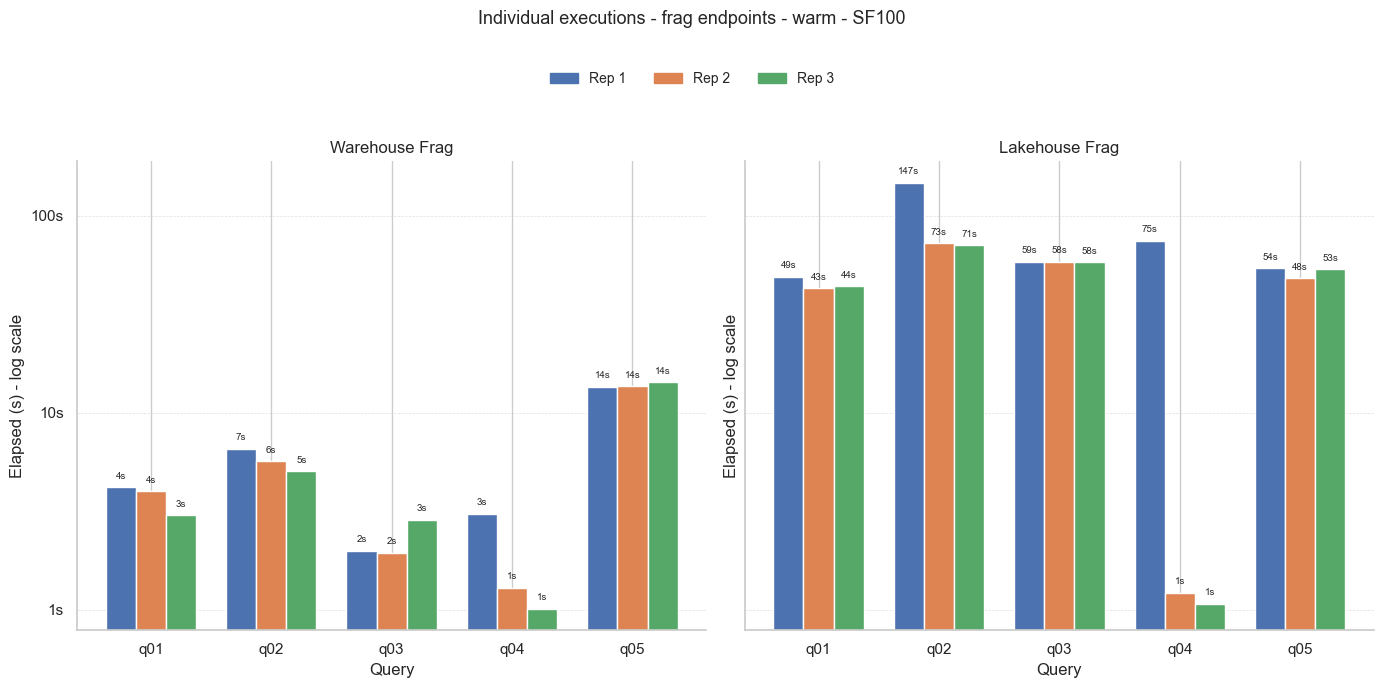

In [9]:
# 8.1 Individual executions - grouped bar chart, shared log Y scale
# run_id is per-execution UUID; median across repeated runs per
# (endpoint, query_id, repetition) to normalise warehouse_frag (6 reps)
# vs lakehouse_frag (3 reps).
_df_frag_all = df_ok[
    df_ok['endpoint'].isin(['warehouse_frag', 'lakehouse_frag']) &
    (df_ok['cache_mode'] == 'warm')
].copy()
if not _df_frag_all.empty:
    _df_frag = (
        _df_frag_all
        .groupby(['endpoint', 'query_id', 'repetition'])['elapsed_ms']
        .median().reset_index()
    )
else:
    _df_frag = pd.DataFrame()

if _df_frag.empty:
    print('No frag results yet - run: py benchmark/runner.py --endpoints warehouse_frag lakehouse_frag --warm-only')
else:
    _df_frag['elapsed_s'] = _df_frag['elapsed_ms'] / 1000
    _queries = sorted(_df_frag['query_id'].unique())
    _reps = sorted(_df_frag['repetition'].unique())
    _rep_colors = {1: '#4c72b0', 2: '#dd8452', 3: '#55a868'}
    _n_reps = len(_reps)
    _width = 0.25
    _x = np.arange(len(_queries))

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    fig.suptitle('Individual executions - frag endpoints - warm - SF100', fontsize=13)

    for ax, endpoint in zip(axes, ['warehouse_frag', 'lakehouse_frag']):
        data = _df_frag[_df_frag['endpoint'] == endpoint]
        for i, rep in enumerate(_reps):
            rd = data[data['repetition'] == rep].set_index('query_id').reindex(_queries)
            vals = rd['elapsed_s'].values
            bars = ax.bar(_x + (i - _n_reps / 2 + 0.5) * _width, vals,
                          width=_width, color=_rep_colors.get(rep, 'grey'),
                          label=f'Rep {rep}', edgecolor='white')
            for bar, v in zip(bars, vals):
                if not np.isnan(v) and v > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.08,
                            f'{v:.0f}s', ha='center', va='bottom', fontsize=7)
        ax.set_title(endpoint.replace('_', ' ').title())
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v:.0f}s' if v >= 1 else f'{v:.1f}s')
        )
        ax.set_xticks(_x)
        ax.set_xticklabels(_queries)
        ax.set_xlabel('Query')
        ax.set_ylabel('Elapsed (s) - log scale')
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
        sns.despine(ax=ax)

    # Shared horizontal legend between title and charts
    _legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=_rep_colors[r]) for r in _reps
    ]
    _legend_labels = [f'Rep {r}' for r in _reps]
    fig.legend(_legend_handles, _legend_labels,
               loc='upper center', ncol=len(_reps),
               bbox_to_anchor=(0.5, 0.91), frameon=False, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.87])
    plt.show()

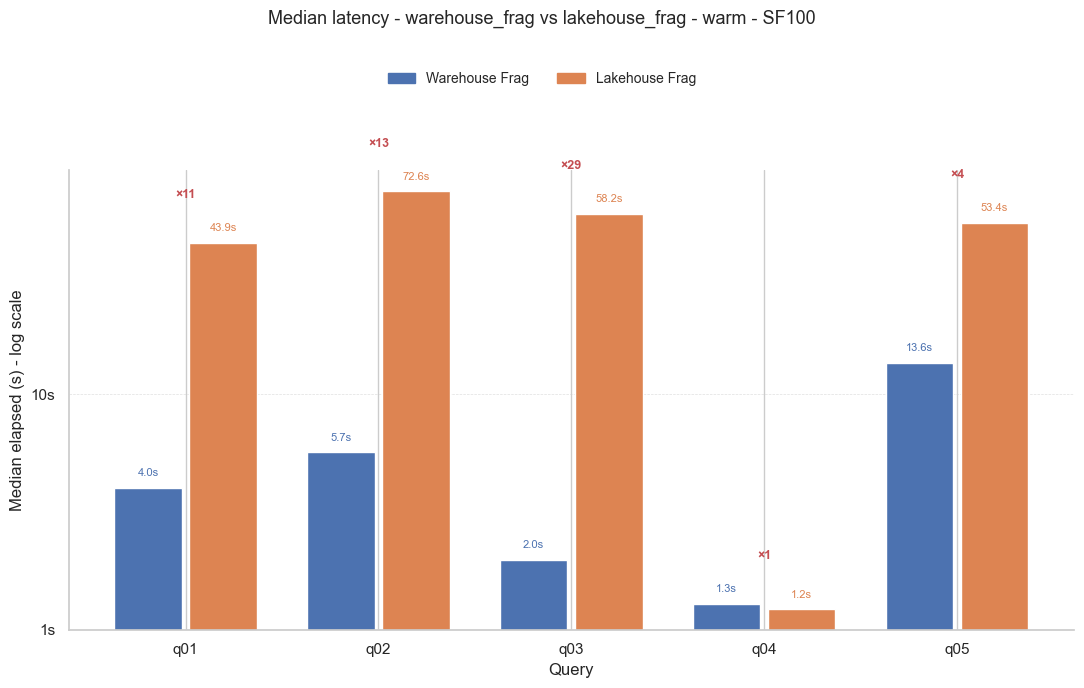


Median latency summary (seconds):
          lakehouse_frag  warehouse_frag  lh_wh_factor_x
query_id                                                
q01                 43.9             4.0            11.0
q02                 72.6             5.7            12.7
q03                 58.2             2.0            29.1
q04                  1.2             1.3             0.9
q05                 53.4            13.6             3.9


In [10]:
# 8.2 Median latency - one grouped chart (log Y), warehouse_frag vs lakehouse_frag
if '_df_frag' in dir() and not _df_frag.empty:
    _means = (
        _df_frag
        .groupby(['endpoint', 'query_id'])['elapsed_s']
        .median().reset_index().rename(columns={'elapsed_s': 'median_s'})
    )
    _queries_avg = sorted(_means['query_id'].unique())
    _ep_colors   = {'warehouse_frag': '#4c72b0', 'lakehouse_frag': '#dd8452'}
    _ep_labels   = {'warehouse_frag': 'Warehouse Frag', 'lakehouse_frag': 'Lakehouse Frag'}
    _endpoints   = ['warehouse_frag', 'lakehouse_frag']
    _n_ep = len(_endpoints)
    _bar_w = 0.35
    _x = np.arange(len(_queries_avg))

    fig, ax = plt.subplots(figsize=(11, 7))
    fig.suptitle(
        'Median latency - warehouse_frag vs lakehouse_frag - warm - SF100',
        fontsize=13
    )

    for i, ep in enumerate(_endpoints):
        ep_data = _means[_means['endpoint'] == ep].set_index('query_id')
        vals = [ep_data.loc[q, 'median_s'] if q in ep_data.index else float('nan')
                for q in _queries_avg]
        xs = _x + (i - (_n_ep - 1) / 2) * (_bar_w + 0.04)
        bars = ax.bar(xs, vals, width=_bar_w,
                      color=_ep_colors[ep], label=_ep_labels[ep], edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v) and v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, v * 1.1,
                        f'{v:.1f}s', ha='center', va='bottom', fontsize=8,
                        color=_ep_colors[ep])

    # Slowdown annotations
    _wh_m = _means[_means['endpoint'] == 'warehouse_frag'].set_index('query_id')
    _lh_m = _means[_means['endpoint'] == 'lakehouse_frag'].set_index('query_id')
    for xi, q in enumerate(_queries_avg):
        if q in _wh_m.index and q in _lh_m.index and _wh_m.loc[q, 'median_s'] > 0:
            factor = _lh_m.loc[q, 'median_s'] / _wh_m.loc[q, 'median_s']
            top = max(_lh_m.loc[q, 'median_s'], _wh_m.loc[q, 'median_s'])
            ax.annotate(f'×{factor:.0f}', xy=(xi, top),
                        ha='center', va='bottom', fontsize=9,
                        color='#c44e52', fontweight='bold',
                        xytext=(0, 30), textcoords='offset points')

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0f}s' if v >= 1 else f'{v:.1f}s')
    )
    ax.set_xticks(_x)
    ax.set_xticklabels(_queries_avg)
    ax.set_xlabel('Query')
    ax.set_ylabel('Median elapsed (s) - log scale')
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)

    # Shared horizontal legend between title and chart
    _legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=_ep_colors[ep]) for ep in _endpoints
    ]
    fig.legend(_legend_handles, [_ep_labels[ep] for ep in _endpoints],
               loc='upper center', ncol=len(_endpoints),
               bbox_to_anchor=(0.5, 0.91), frameon=False, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.87])
    plt.show()

    # Summary table
    _pivot = _means.pivot(index='query_id', columns='endpoint', values='median_s').round(1)
    _pivot.columns.name = None
    if 'warehouse_frag' in _pivot.columns and 'lakehouse_frag' in _pivot.columns:
        _pivot['lh_wh_factor_x'] = (_pivot['lakehouse_frag'] / _pivot['warehouse_frag']).round(1)
    print('\nMedian latency summary (seconds):')
    print(_pivot.to_string())


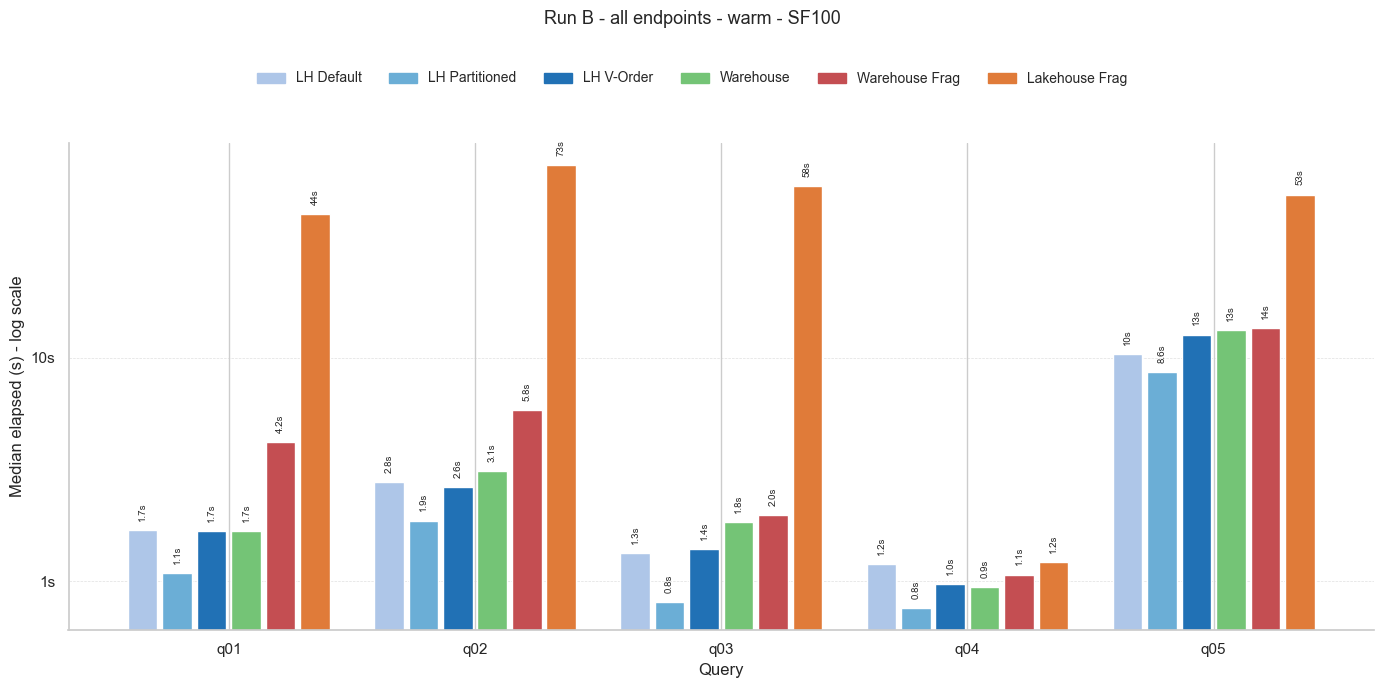


Fragmentation slowdown factor (fragmented / compact):
   engine query_id   compact  fragmented  slowdown_x
lakehouse      q01  1086.455   43911.510        40.4
lakehouse      q02  1866.305   72599.510        38.9
lakehouse      q03   810.260   58240.610        71.9
lakehouse      q04   759.775    1218.330         1.6
lakehouse      q05  8588.800   53400.140         6.2
warehouse      q01  1676.555    4178.660         2.5
warehouse      q02  3116.080    5842.880         1.9
warehouse      q03  1834.850    1982.860         1.1
warehouse      q04   943.610    1070.595         1.1
warehouse      q05 13306.405   13525.590         1.0


In [11]:
_FRAG_EPS = ['lakehouse_frag', 'warehouse_frag']
_CONFIG_MAP = {
    'lakehouse_default':     ('lakehouse', 'compact'),
    'lakehouse_partitioned': ('lakehouse', 'compact'),
    'lakehouse_vorder':      ('lakehouse', 'compact'),
    'warehouse':             ('warehouse', 'compact'),
    'lakehouse_frag':        ('lakehouse', 'fragmented'),
    'warehouse_frag':        ('warehouse', 'fragmented'),
}

if df_ok[df_ok['endpoint'].isin(_FRAG_EPS)].empty:
    print('No fragmentation results yet.')
else:
    # â”€â”€ Chart 8.3: Run B - all compact endpoints + warehouse_frag  â”€â”€â”€â”€â”€â”€
    _runb_eps = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder',
                 'warehouse', 'warehouse_frag', 'lakehouse_frag']
    _df_runb = (
        df_ok[df_ok['endpoint'].isin(_runb_eps) & (df_ok['cache_mode'] == 'warm')]
        .groupby(['endpoint', 'query_id'])['elapsed_ms']
        .median().reset_index()
    )
    _runb_queries = sorted(_df_runb['query_id'].unique())
    _ep_order = ['lakehouse_default', 'lakehouse_partitioned', 'lakehouse_vorder',
                 'warehouse', 'warehouse_frag', 'lakehouse_frag']
    _ep_colors_b = {
        'lakehouse_default':    '#aec6e8',
        'lakehouse_partitioned':'#6baed6',
        'lakehouse_vorder':     '#2171b5',
        'warehouse':            '#74c476',
        'warehouse_frag':       '#c44e52',
        'lakehouse_frag':       '#e07b39',
    }
    _ep_labels_b = {
        'lakehouse_default':    'LH Default',
        'lakehouse_partitioned':'LH Partitioned',
        'lakehouse_vorder':     'LH V-Order',
        'warehouse':            'Warehouse',
        'warehouse_frag':       'Warehouse Frag',
        'lakehouse_frag':       'Lakehouse Frag',
    }
    _n_ep_b = len(_ep_order)
    _bar_w_b = 0.12
    _x_b = np.arange(len(_runb_queries))

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.suptitle(
        'Run B - all endpoints - warm - SF100',
        fontsize=13
    )

    for i, ep in enumerate(_ep_order):
        ep_data = _df_runb[_df_runb['endpoint'] == ep].set_index('query_id')
        vals = [ep_data.loc[q, 'elapsed_ms'] / 1000 if q in ep_data.index else float('nan')
                for q in _runb_queries]
        xs = _x_b + (i - (_n_ep_b - 1) / 2) * (_bar_w_b + 0.02)
        ax.bar(xs, vals, width=_bar_w_b,
               color=_ep_colors_b[ep], label=_ep_labels_b[ep], edgecolor='white')
        for xi, v in zip(xs, vals):
            if not np.isnan(v) and v > 0:
                ax.text(xi, v * 1.1,
                        f'{v:.0f}s' if v >= 10 else f'{v:.1f}s',
                        ha='center', va='bottom', fontsize=7, rotation=90)

    _handles_b = [plt.Rectangle((0, 0), 1, 1, color=_ep_colors_b[ep]) for ep in _ep_order]
    fig.legend(_handles_b, [_ep_labels_b[ep] for ep in _ep_order],
               loc='upper center', ncol=_n_ep_b,
               bbox_to_anchor=(0.5, 0.91), frameon=False, fontsize=10)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0f}s' if v >= 1 else f'{v:.2f}s')
    )
    ax.set_xticks(list(_x_b))
    ax.set_xticklabels(_runb_queries)
    ax.set_xlabel('Query')
    ax.set_ylabel('Median elapsed (s) - log scale')
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)
    plt.tight_layout(rect=[0, 0, 1, 0.87])
    plt.show()

    # Slowdown summary table
    df_frag2 = df_ok.copy()
    df_frag2[['engine', 'config']] = pd.DataFrame(
        df_frag2['endpoint'].map(_CONFIG_MAP).tolist(), index=df_frag2.index
    )
    present_engines = df_frag2[df_frag2['config'] == 'fragmented']['engine'].unique()
    df_frag2 = df_frag2[df_frag2['engine'].isin(present_engines)]

    compact2 = (
        df_frag2[(df_frag2['config'] == 'compact') & (df_frag2['cache_mode'] == 'warm')]
        .groupby(['engine', 'endpoint', 'query_id'])['elapsed_ms']
        .median().reset_index()
    )
    best_compact2 = (
        compact2.groupby(['engine', 'query_id'])['elapsed_ms']
        .min().reset_index().rename(columns={'elapsed_ms': 'min_median'})
    )
    compact2 = compact2.merge(best_compact2, on=['engine', 'query_id'])
    compact2 = compact2[compact2['elapsed_ms'] == compact2['min_median']].drop_duplicates(['engine', 'query_id'])

    frag_summary2 = (
        df_frag2[(df_frag2['config'] == 'fragmented') & (df_frag2['cache_mode'] == 'warm')]
        .groupby(['engine', 'query_id'])['elapsed_ms']
        .median().reset_index()
    )

    pivot2 = compact2[['engine', 'query_id', 'elapsed_ms']].rename(columns={'elapsed_ms': 'compact'}).merge(
        frag_summary2[['engine', 'query_id', 'elapsed_ms']].rename(columns={'elapsed_ms': 'fragmented'}),
        on=['engine', 'query_id'], how='outer'
    )
    pivot2['slowdown_x'] = (pivot2['fragmented'] / pivot2['compact']).round(1)
    print()
    print('Fragmentation slowdown factor (fragmented / compact):')
    print(pivot2[['engine', 'query_id', 'compact', 'fragmented', 'slowdown_x']].to_string(index=False))
